# **Complete repository step-by-step diagnostics.**

In [2]:
from typing import Callable, Any, Optional

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as e:
        if expected_valid:
            print(f"[ANOMALY] {label}: Expected success but failed with {type(e).__name__}({e})")
        else:
            print(f"[CORRECT] {label}: Failed as expected with {type(e).__name__}({e})")
        return None
    else:
        if expected_valid:
            print(f"[CORRECT] {label}: Succeeded as expected.")
            return result
        else:
            print(f"[ANOMALY] {label}: Expected failure but succeeded.")
            return result

## **Node** (in node.py)

--- NODE TESTS ---
[CORRECT] Node(124.2, 8.2, 0): Succeeded as expected.
[CORRECT] Node(124.2, 8.2, 1): Succeeded as expected.
[CORRECT] Node(124.2, 8.2, 2): Succeeded as expected.
[CORRECT] Node(124.2, 8.2, 3): Succeeded as expected.
[CORRECT] Node(124.2, 8.2, None): Succeeded as expected.
[CORRECT] Node(124.2, 8.2, 4): Failed as expected with ValueError([NODE] Invalid layer value 4. Must be an integer from 0 to 3, or None.)
[CORRECT] Node(124.2, 8.2, -1): Failed as expected with ValueError([NODE] Invalid layer value -1. Must be an integer from 0 to 3, or None.)
[CORRECT] Node(181, 8.2, 0): Failed as expected with ValueError([NODE] Invalid lon value 181. Must be a number from -180 to 180.)
[CORRECT] Node(-181, 8.2, 0): Failed as expected with ValueError([NODE] Invalid lon value -181. Must be a number from -180 to 180.)
[CORRECT] Node(124.2, 91, 0): Failed as expected with ValueError([NODE] Invalid lat value 91. Must be a number from -90 to 90.)
[CORRECT] Node(124.2, -91, 0): Failed as

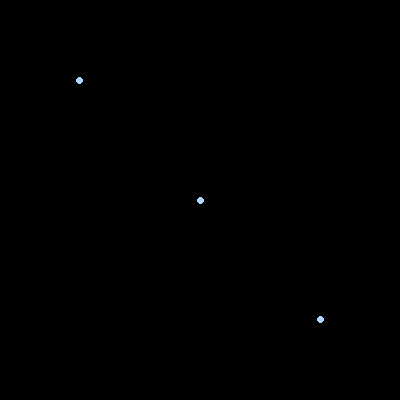

In [6]:
from utils.node import Node
from PIL import Image
from IPython.display import display

print("--- NODE TESTS ---")

# Valid construction
test_node_configs = [
    (124.2, 8.2, 0, True),
    (124.2, 8.2, 1, True),
    (124.2, 8.2, 2, True),
    (124.2, 8.2, 3, True),
    (124.2, 8.2, None, True),
]

for lon, lat, layer, expected in test_node_configs:
    label = f"Node({lon}, {lat}, {layer})"
    if layer is None:
        node = validate_call(label, expected, Node, lon, lat)
    else:
        node = validate_call(label, expected, Node, lon, lat, layer)

# Invalid layer values
invalid_layer_configs = [
    (124.2, 8.2, 4),
    (124.2, 8.2, -1),
]

for lon, lat, layer in invalid_layer_configs:
    validate_call(f"Node({lon}, {lat}, {layer})", False, Node, lon, lat, layer)

# Invalid coordinates
invalid_coord_configs = [
    (181, 8.2, 0),
    (-181, 8.2, 0),
    (124.2, 91, 0),
    (124.2, -91, 0),
]

for lon, lat, layer in invalid_coord_configs:
    validate_call(f"Node({lon}, {lat}, {layer})", False, Node, lon, lat, layer)

# Immutability + unique IDs
n1 = Node(124.2, 8.2, 0)
n2 = Node(124.2, 8.2, 0)

assert n1.id != n2.id, "Node IDs should be unique"
assert isinstance(n1.id, str) and n1.id.startswith("N"), "Node ID should be a string"
assert n1.lon == 124.2 and n1.lat == 8.2, "Node coordinates should be preserved"

try:
    n1.lon = 125.0
    raise AssertionError("Node.lon should be immutable")
except AttributeError:
    pass

try:
    n1.lat = 9.0
    raise AssertionError("Node.lat should be immutable")
except AttributeError:
    pass

print("\n--- VISUALIZATION TEST ---")
img_node = Image.new("RGB", (400, 400), "black")
context = ((124.20, 8.30), (124.30, 8.20))
vis_nodes = [
    Node(124.22, 8.28, 0),
    Node(124.28, 8.22, 1),
    Node(124.25, 8.25, 2)
]
for n in vis_nodes:
    n.draw(context, img_node)
display(img_node)

## **DirEdge** (in directed_edge.py)

In [ ]:
from utils.node import Node
from utils.directed_edge import DirEdge, _stitch
from PIL import Image
from IPython.display import display

n1l1 = Node(124.2384, 8.2393, 1) 
n2l1 = Node(124.243862, 8.237768, 1) 
n3l1 = Node(124.238, 8.239, 1) 

n1l2 = Node(124.2384, 8.2393, 2)
n2l2 = Node(124.243862, 8.237768, 2)
n3l2 = Node(124.238, 8.239, 2)

n1l3 = Node(124.2384, 8.2393, 3)
n2l3 = Node(124.243862, 8.237768, 3)
n3l3 = Node(124.238, 8.239, 3)

n1l0 = Node(124.2384, 8.2393, 0)
n2l0 = Node(124.243862, 8.237768, 0)
n3l0 = Node(124.238, 8.239, 0)

test_dir_configs = [
    (n1l1, n2l1, True),
    (None, n2l1, False),
    (n1l1, None, False),
    (n1l1, n1l1, False),
    (n1l1, n2l0, False)
]

print("\n--- DIR EDGE CONFIG TESTS ---")
for config in test_dir_configs:
    start_node, end_node, expected = config
    result = validate_call(
        f"DirEdge({start_node}, {end_node})",
        expected,
        DirEdge,
        start_node,
        end_node
    )
    
print("\n--- STITCHING TEST ---")
dir_edges_s = [DirEdge(n1l1, n2l1), DirEdge(n2l1, n3l1)]
dir_edges_e = [DirEdge(n1l2, n2l2), DirEdge(n2l1, n2l2)] 
validate_call(
    "_stitch(dir_edges_s, dir_edges_e, weight=2, verbose=True)",
    True,
    _stitch,
    dir_edges_s,
    dir_edges_e,
    weight=2,
    verbose=True
)
for edge in dir_edges_s + dir_edges_e:
    print(f"{edge} is connected to {edge.next_edges}")

print("\n--- LENGTH TEST ---")
print("Great-Circle Distance of MSU-IIT to 7-11 MSU-IIT:")
print(DirEdge(n1l1, n2l1).getLength())

print("\n--- TYPE TEST ---")
typeTestConfigs = [
    (n1l1, n2l1, True),
    (n1l3, n1l3, False),
    (n1l1, n2l0, False),
]

for config in typeTestConfigs:
    start_node, end_node, expected = config
    dir_edge = validate_call(
        f"DirEdge({start_node}, {end_node})",
        expected,
        DirEdge,
        start_node,
        end_node
    )
    if dir_edge is not None:
        print(f"Type: {dir_edge.getType()}")

print("\n--- VISUALIZATION TEST ---")
img_edge = Image.new("RGB", (400, 400), "black")
context_edge = ((124.230, 8.245), (124.250, 8.235))

vis_e1 = DirEdge(n1l1, n2l1)
vis_e2 = DirEdge(n2l1, n3l1)

vis_e1.draw(context_edge, img_edge)
vis_e2.draw(context_edge, img_edge)

# Draw nodes on top to verify alignment
n1l1.draw(context_edge, img_edge)
n2l1.draw(context_edge, img_edge)
n3l1.draw(context_edge, img_edge)

display(img_edge)

SyntaxError: invalid syntax (2177993606.py, line 53)

## **CityGraph** (in city_graph.py)